<a href="https://colab.research.google.com/github/njwbilll/finalterm-machine-learning/blob/main/1_Online_Transaction_UAS_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UAS Machine Learning -- End-to-End Fraud Detection Pipeline

**Nama:** Najwa Bilqis Al Khalidah
**NIM:** 101032300186
**Kelas:** TK-46-GAB

---

## Deskripsi Proyek

Notebook ini merupakan implementasi end-to-end pipeline machine learning untuk mendeteksi
transaksi online yang bersifat penipuan (fraud). Pipeline mencakup:

1. Pengunduhan dan pemuatan dataset dari Google Drive
2. Eksplorasi data (EDA)
3. Preprocessing dan feature engineering
4. Penanganan class imbalance
5. Pelatihan model (Logistic Regression, Random Forest, XGBoost, LightGBM)
6. Hyperparameter tuning menggunakan Optuna
7. Evaluasi model menggunakan berbagai metrik
8. Pelacakan eksperimen menggunakan MLflow

Dataset yang digunakan: train_transaction.csv

# 1. INSTALASI
Instalasi Library yang Dibutuhkan


In [ ]:
# Install semua library yang diperlukan
!pip install gdown optuna mlflow lightgbm xgboost imbalanced-learn scikit-learn pandas numpy matplotlib seaborn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 899.1 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/


#  2. IMPORT
Import Library


In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import xgboost as xgb
import lightgbm as lgb
import optuna
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

np.random.seed(42)
print("Semua library berhasil diimport.")
print("Versi utama:")
print(f"  pandas     : {pd.__version__}")
print(f"  scikit-learn: {__import__('sklearn').__version__}")
print(f"  xgboost    : {xgb.__version__}")
print(f"  lightgbm   : {lgb.__version__}")
print(f"  optuna     : {optuna.__version__}")
print(f"  mlflow     : {mlflow.__version__}")

Semua library berhasil diimport.
Versi utama:
  pandas     : 2.2.2
  scikit-learn: 1.6.1
  xgboost    : 3.2.0
  lightgbm   : 4.6.0
  optuna     : 4.9.0
  mlflow     : 3.14.0


# 3. DOWNLOAD DATASET
Dataset train_transaction.csv diunduh dari Google Drive menggunakan gdown.
File ID diambil dari link sharing Google Drive.

In [ ]:
import gdown

FILE_ID = "14uTgvnaN9RX1faLuZYEBVtVfw5LOaw8p"
OUTPUT_PATH = "train_transaction.csv"

if not os.path.exists(OUTPUT_PATH):
    print("Mengunduh dataset dari Google Drive...")
    gdown.download(
        f"https://drive.google.com/uc?id={FILE_ID}",
        OUTPUT_PATH,
        quiet=False
    )
    print("Unduhan selesai.")
else:
    print("Dataset sudah tersedia di lokal, melewati unduhan.")

print(f"Ukuran file: {os.path.getsize(OUTPUT_PATH) / 1e6:.1f} MB")

Mengunduh dataset dari Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=14uTgvnaN9RX1faLuZYEBVtVfw5LOaw8p
From (redirected): https://drive.google.com/uc?id=14uTgvnaN9RX1faLuZYEBVtVfw5LOaw8p&confirm=t&uuid=98650d2e-3c96-4eb4-b013-f33280a80268
To: /content/train_transaction.csv
100%|██████████| 683M/683M [00:12<00:00, 54.7MB/s]

Unduhan selesai.
Ukuran file: 683.4 MB


## 4. Pemuatan dan Eksplorasi Awal Data

Dataset dimuat menggunakan pandas. Karena ukurannya besar, kita gunakan
`dtype` yang efisien untuk mengurangi penggunaan memori

In [ ]:
# Muat dataset
print("Memuat dataset...")
df = pd.read_csv(OUTPUT_PATH)
print(f"Ukuran dataset: {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"Penggunaan memori: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()
print("Kolom pertama dan tipe datanya:")
print(df.dtypes.head(20))

# Tampilkan 5 baris pertama
df.head()

# Informasi dasar dataset
print("=== Informasi Dataset ===")
print(f"Jumlah fitur numerik  : {df.select_dtypes(include=[np.number]).shape[1]}")
print(f"Jumlah fitur kategori : {df.select_dtypes(include=['object']).shape[1]}")
print()

# Distribusi label target
fraud_counts = df["isFraud"].value_counts()
fraud_pct = df["isFraud"].value_counts(normalize=True) * 100

print("=== Distribusi Label Target (isFraud) ===")
print(f"Transaksi normal (0) : {fraud_counts[0]:,} ({fraud_pct[0]:.2f}%)")
print(f"Transaksi fraud  (1) : {fraud_counts[1]:,} ({fraud_pct[1]:.2f}%)")
print()
print("Dataset sangat tidak seimbang (imbalanced). Perlu penanganan khusus.")

Memuat dataset...
Ukuran dataset: 590,540 baris x 394 kolom
Penggunaan memori: 2162.2 MB

Kolom pertama dan tipe datanya:
TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD          object
card1               int64
card2             float64
card3             float64
card4              object
card5             float64
card6              object
addr1             float64
addr2             float64
dist1             float64
dist2             float64
P_emaildomain      object
R_emaildomain      object
C1                float64
C2                float64
C3                float64
dtype: object
=== Informasi Dataset ===
Jumlah fitur numerik  : 380
Jumlah fitur kategori : 14

=== Distribusi Label Target (isFraud) ===
Transaksi normal (0) : 569,877 (96.50%)
Transaksi fraud  (1) : 20,663 (3.50%)

Dataset sangat tidak seimbang (imbalanced). Perlu penanganan khusus.


# 5. EDA
#Eksplorasi Data (EDA)

Analisis distribusi fitur, nilai hilang (missing values),
dan hubungan antar fitur dengan label target.

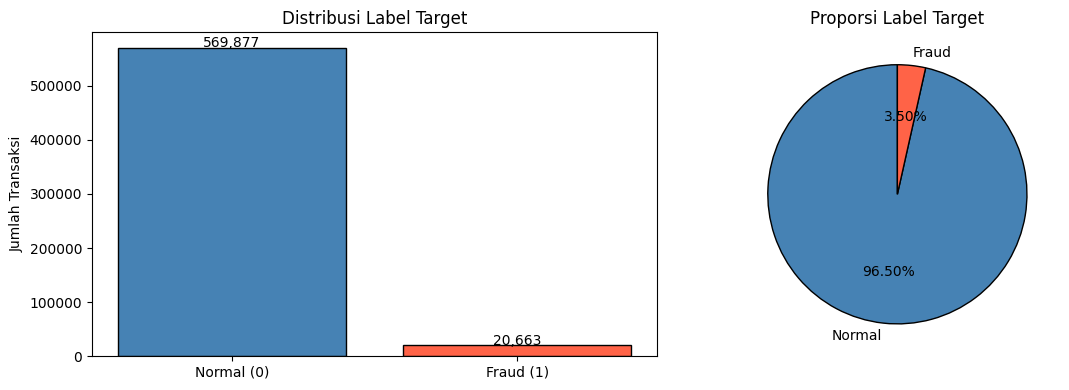

Gambar disimpan sebagai label_distribution.png
=== Analisis Missing Values ===
Kolom dengan missing values: 20 dari 394 kolom

       Jumlah Missing  Persentase (%)
dist2          552913       93.628374
D7             551623       93.409930
D13            528588       89.509263
D14            528353       89.469469
D12            525823       89.041047
D6             517353       87.606767
D9             515614       87.312290
D8             515614       87.312290
V153           508595       86.123717
V149           508595       86.123717
V141           508595       86.123717
V146           508595       86.123717
V154           508595       86.123717
V162           508595       86.123717
V142           508595       86.123717
V158           508595       86.123717
V161           508595       86.123717
V157           508595       86.123717
V138           508595       86.123717
V139           508595       86.123717


In [ ]:
# Visualisasi distribusi label
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(["Normal (0)", "Fraud (1)"], fraud_counts.values,
            color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Distribusi Label Target")
axes[0].set_ylabel("Jumlah Transaksi")
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=10)

axes[1].pie(fraud_counts.values, labels=["Normal", "Fraud"],
            autopct="%1.2f%%", colors=["steelblue", "tomato"],
            startangle=90, wedgeprops=dict(edgecolor="black"))
axes[1].set_title("Proporsi Label Target")

plt.tight_layout()
plt.savefig("label_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print("Gambar disimpan sebagai label_distribution.png")

# Analisis missing values
print("=== Analisis Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    "Jumlah Missing": missing,
    "Persentase (%)": missing_pct
}).sort_values("Persentase (%)", ascending=False)

# Tampilkan kolom dengan missing values terbanyak
top_missing = missing_df[missing_df["Jumlah Missing"] > 0].head(20)
print(f"Kolom dengan missing values: {len(top_missing)} dari {df.shape[1]} kolom")
print()
print(top_missing.to_string())



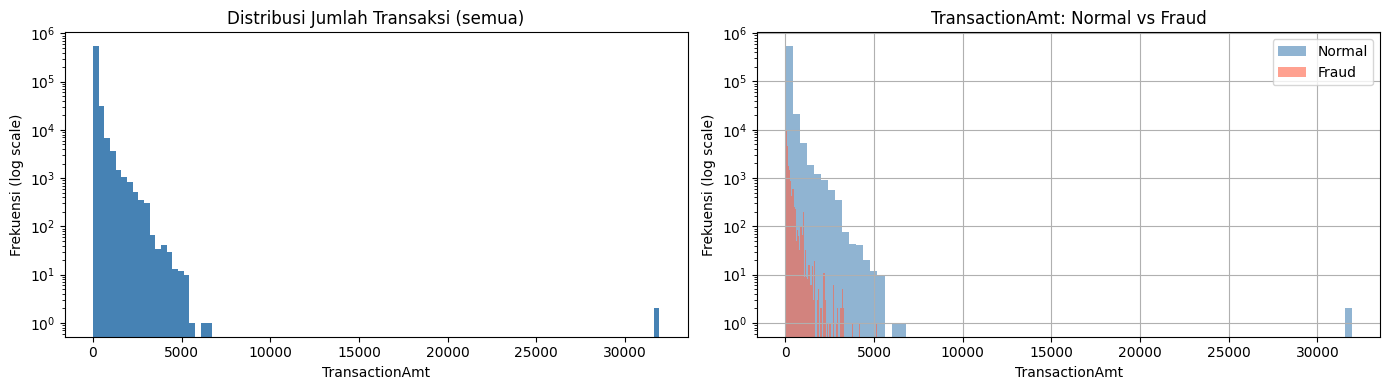

In [ ]:
# Distribusi TransactionAmt (jumlah transaksi)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["TransactionAmt"], bins=100, color="steelblue", edgecolor="none", log=True)
axes[0].set_xlabel("TransactionAmt")
axes[0].set_ylabel("Frekuensi (log scale)")
axes[0].set_title("Distribusi Jumlah Transaksi (semua)")

# Bandingkan distribusi TransactionAmt antara fraud vs normal
df[df["isFraud"] == 0]["TransactionAmt"].hist(
    bins=80, ax=axes[1], alpha=0.6, color="steelblue", label="Normal", log=True)
df[df["isFraud"] == 1]["TransactionAmt"].hist(
    bins=80, ax=axes[1], alpha=0.6, color="tomato", label="Fraud", log=True)
axes[1].set_xlabel("TransactionAmt")
axes[1].set_ylabel("Frekuensi (log scale)")
axes[1].set_title("TransactionAmt: Normal vs Fraud")
axes[1].legend()

plt.tight_layout()
plt.savefig("transaction_amt_dist.png", dpi=120, bbox_inches="tight")
plt.show()

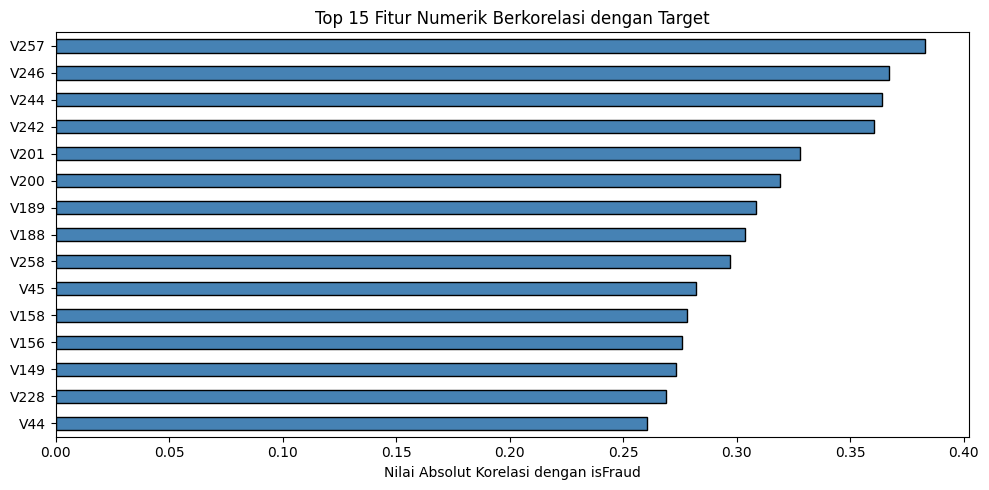

In [ ]:
# Korelasi fitur numerik dengan target
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "isFraud"]

corr_with_target = df[num_cols + ["isFraud"]].corr()["isFraud"].drop("isFraud")
top_corr = corr_with_target.abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
top_corr.sort_values().plot(kind="barh", color="steelblue", edgecolor="black")
plt.xlabel("Nilai Absolut Korelasi dengan isFraud")
plt.title("Top 15 Fitur Numerik Berkorelasi dengan Target")
plt.tight_layout()
plt.savefig("feature_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

# 6. PREPROCESSING
Tahap ini mencakup:
- Pemilihan fitur berdasarkan threshold missing values
- Encoding fitur kategorikal
- Imputasi nilai hilang
- Pembuatan fitur baru (feature engineering)
- Pemisahan data latih dan data uji

In [ ]:
# Hapus kolom dengan missing values lebih dari 50%
MISSING_THRESHOLD = 0.5
cols_to_drop = missing_df[missing_df["Persentase (%)"] > MISSING_THRESHOLD * 100].index.tolist()
print(f"Kolom yang dihapus (missing > {MISSING_THRESHOLD*100:.0f}%): {len(cols_to_drop)}")
print(cols_to_drop[:10], "...")

df_clean = df.drop(columns=cols_to_drop)
print(f"\\nUkuran setelah penghapusan kolom: {df_clean.shape}")

Kolom yang dihapus (missing > 50%): 174
['dist2', 'D7', 'D13', 'D14', 'D12', 'D6', 'D9', 'D8', 'V153', 'V149'] ...
\nUkuran setelah penghapusan kolom: (590540, 220)


In [ ]:
# Feature Engineering: buat fitur baru dari TransactionAmt
df_clean["TransactionAmt_log"]    = np.log1p(df_clean["TransactionAmt"])
df_clean["TransactionAmt_decimal"] = df_clean["TransactionAmt"] - df_clean["TransactionAmt"].astype(int)

# Fitur waktu: apakah transaksi terjadi di jam sibuk
# TransactionDT dalam detik sejak referensi; konversi ke jam dalam sehari
df_clean["hour_of_day"] = (df_clean["TransactionDT"] / 3600) % 24
df_clean["is_night"]    = ((df_clean["hour_of_day"] >= 22) | (df_clean["hour_of_day"] <= 5)).astype(int)
df_clean["day_of_week"] = (df_clean["TransactionDT"] / (3600 * 24)) % 7

print("Fitur baru yang ditambahkan:")
new_feats = ["TransactionAmt_log", "TransactionAmt_decimal", "hour_of_day", "is_night", "day_of_week"]
print(df_clean[new_feats].describe().round(3))

Fitur baru yang ditambahkan:
       TransactionAmt_log  TransactionAmt_decimal  hour_of_day    is_night  \
count          590540.000              590540.000   590540.000  590540.000   
mean                4.383                   0.379       14.363       0.362   
std                 0.937                   0.434        7.619       0.481   
min                 0.224                   0.000        0.000       0.000   
25%                 3.791                   0.000        6.786       0.000   
50%                 4.245                   0.000       16.840       0.000   
75%                 4.836                   0.950       20.409       1.000   
max                10.372                   0.999       24.000       1.000   

       day_of_week  
count   590540.000  
mean         3.556  
std          2.053  
min          0.000  
25%          1.780  
50%          3.681  
75%          5.279  
max          7.000  


In [ ]:
# Pisahkan fitur dan target
TARGET = "isFraud"
DROP_COLS = ["TransactionID", "TransactionDT"]

# Kolom yang akan dipakai
use_cols = [c for c in df_clean.columns if c not in DROP_COLS + [TARGET]]

X = df_clean[use_cols].copy()
y = df_clean[TARGET].copy()

print(f"Ukuran fitur X : {X.shape}")
print(f"Ukuran target y: {y.shape}")
print(f"Distribusi y   : fraud={y.sum():,} ({y.mean()*100:.2f}%)")

Ukuran fitur X : (590540, 222)
Ukuran target y: (590540,)
Distribusi y   : fraud=20,663 (3.50%)


In [ ]:
# Encoding fitur kategorikal dengan Label Encoding
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
print(f"Fitur kategorikal yang di-encode: {len(cat_cols)} kolom")
print(cat_cols)

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = X[col].astype(str)
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

print("\\nEncoding selesai. Semua kolom sekarang numerik.")
print(f"Tipe data setelah encoding:\\n{X.dtypes.value_counts()}")

Fitur kategorikal yang di-encode: 9 kolom
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M6']
\nEncoding selesai. Semua kolom sekarang numerik.
Tipe data setelah encoding:\nfloat64    211
int64       11
Name: count, dtype: int64


In [ ]:
# Train-test split dengan stratifikasi
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Ukuran data latih : {X_train.shape[0]:,} sampel")
print(f"Ukuran data uji   : {X_test.shape[0]:,} sampel")
print(f"Fraud di data latih: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Fraud di data uji : {y_test.sum():,} ({y_test.mean()*100:.2f}%)")

Ukuran data latih : 472,432 sampel
Ukuran data uji   : 118,108 sampel
Fraud di data latih: 16,530 (3.50%)
Fraud di data uji : 4,133 (3.50%)


In [ ]:
# Imputasi nilai hilang dengan median (untuk fitur numerik)
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

X_train_imp = pd.DataFrame(X_train_imp, columns=X_train.columns)
X_test_imp  = pd.DataFrame(X_test_imp,  columns=X_test.columns)

print("Imputasi selesai.")
print(f"Missing values di train setelah imputasi: {X_train_imp.isnull().sum().sum()}")
print(f"Missing values di test setelah imputasi : {X_test_imp.isnull().sum().sum()}")

Imputasi selesai.
Missing values di train setelah imputasi: 0
Missing values di test setelah imputasi : 0


# 7. PENANGANAN IMBALANCE

Karena rasio fraud sangat kecil (sekitar 3.5%), model akan bias ke kelas mayoritas.
Kita gunakan SMOTE (Synthetic Minority Oversampling Technique) untuk menyeimbangkan
data latih secara sintetis.

Catatan: SMOTE hanya diterapkan pada data latih, bukan data uji.

In [ ]:
# Terapkan SMOTE pada data latih
print("Menerapkan SMOTE pada data latih...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_imp, y_train)

print(f"Sebelum SMOTE: {X_train_imp.shape[0]:,} sampel "
      f"(fraud: {y_train.sum():,} = {y_train.mean()*100:.2f}%)")
print(f"Setelah SMOTE: {X_train_res.shape[0]:,} sampel "
      f"(fraud: {y_train_res.sum():,} = {y_train_res.mean()*100:.2f}%)")

Menerapkan SMOTE pada data latih...
Sebelum SMOTE: 472,432 sampel (fraud: 16,530 = 3.50%)
Setelah SMOTE: 911,804 sampel (fraud: 455,902 = 50.00%)


In [ ]:
# Cell BARU -- taruh langsung di bawah cell SMOTE
del df, df_clean, X, X_train, X_test
import gc
gc.collect()
print("Memori dibebaskan.")

Memori dibebaskan.


# 8. FUNGSI EVALUASI

Kita definisikan fungsi reusable untuk mengevaluasi model dan mencatat hasilnya ke MLflow.

In [ ]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name, log_mlflow=True):
    # Prediksi probabilitas dan label
    y_pred_proba = model.predict_proba(X_te)[:, 1]
    y_pred       = model.predict(X_te)

    # Hitung metrik
    metrics = {
        "roc_auc"       : roc_auc_score(y_te, y_pred_proba),
        "avg_precision" : average_precision_score(y_te, y_pred_proba),
        "f1_score"      : f1_score(y_te, y_pred),
        "precision"     : precision_score(y_te, y_pred),
        "recall"        : recall_score(y_te, y_pred),
    }

    # Tampilkan hasil
    print(f"\n=== Evaluasi: {model_name} ===")
    print(f"  ROC-AUC          : {metrics['roc_auc']:.4f}")
    print(f"  Average Precision: {metrics['avg_precision']:.4f}")
    print(f"  F1 Score         : {metrics['f1_score']:.4f}")
    print(f"  Precision        : {metrics['precision']:.4f}")
    print(f"  Recall           : {metrics['recall']:.4f}")
    print()
    print("  Classification Report:")
    print(classification_report(y_te, y_pred, target_names=["Normal", "Fraud"]))

    # Log ke MLflow
    if log_mlflow:
        with mlflow.start_run(run_name=model_name, nested=True):
            mlflow.log_params({"model": model_name})
            mlflow.log_metrics(metrics)
            mlflow.sklearn.log_model(model, artifact_path="model")

    return metrics, y_pred, y_pred_proba


def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Fraud"],
                yticklabels=["Normal", "Fraud"])
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"cm_{title.replace(' ', '_').lower()}.png", dpi=120)
    plt.show()


print("Fungsi evaluasi berhasil didefinisikan.")

Fungsi evaluasi berhasil didefinisikan.


# 9. BASELINE MODEL: LOGISTIC REGRESSION

Logistic Regression digunakan sebagai baseline untuk memberikan tolok ukur performa
sebelum mencoba model yang lebih kompleks.

In [ ]:
# Setup MLflow experiment
mlflow.set_experiment("fraud-detection-uas")
print("MLflow experiment: fraud-detection-uas")
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")

2026/06/23 03:00:41 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/23 03:00:41 INFO mlflow.store.db.utils: Updating database tables
2026/06/23 03:00:45 INFO mlflow.tracking.fluent: Experiment with name 'fraud-detection-uas' does not exist. Creating a new experiment.


MLflow experiment: fraud-detection-uas
MLflow tracking URI: sqlite:////content/mlflow.db


Melatih Logistic Regression (baseline)...
Logistic Regression selesai dilatih.

=== Evaluasi: Logistic Regression ===
  ROC-AUC          : 0.8308
  Average Precision: 0.3054
  F1 Score         : 0.1794
  Precision        : 0.1023
  Recall           : 0.7297

  Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.77      0.86    113975
       Fraud       0.10      0.73      0.18      4133

    accuracy                           0.77    118108
   macro avg       0.54      0.75      0.52    118108
weighted avg       0.96      0.77      0.84    118108



2026/06/23 03:38:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


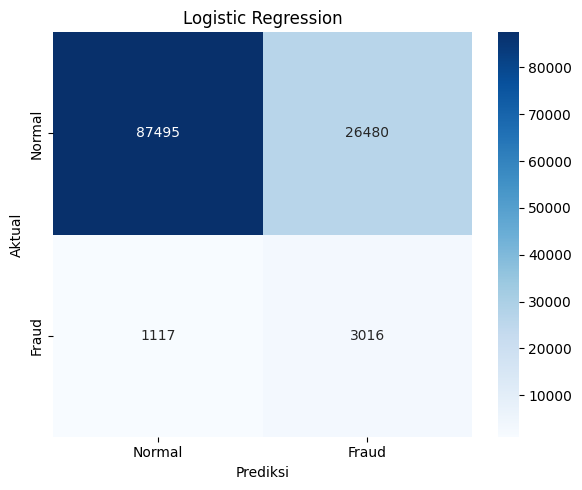

In [ ]:
# Latih Logistic Regression sebagai baseline
print("Melatih Logistic Regression (baseline)...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test_imp)

lr_model = LogisticRegression(
    C=0.1,
    max_iter=500,
    solver="saga",
    n_jobs=-1,
    random_state=42
)
lr_model.fit(X_train_scaled, y_train_res)
print("Logistic Regression selesai dilatih.")

lr_metrics, lr_pred, lr_proba = evaluate_model(
    lr_model, X_train_scaled, y_train_res,
    X_test_scaled, y_test,
    model_name="Logistic Regression"
)
plot_confusion_matrix(y_test, lr_pred, "Logistic Regression")

# 10. RANDOM FOREST

Random Forest adalah ensemble dari banyak decision tree. Setiap tree dilatih pada
subset acak dari data (bootstrap) dan fitur. Prediksi akhir adalah mayoritas suara.
Random Forest lebih tahan terhadap overfitting dibandingkan single decision tree.

Melatih Random Forest...
Random Forest selesai dilatih.


2026/06/23 03:52:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



=== Evaluasi: Random Forest ===
  ROC-AUC          : 0.8854
  Average Precision: 0.5195
  F1 Score         : 0.4569
  Precision        : 0.3924
  Recall           : 0.5468

  Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.97      0.98    113975
       Fraud       0.39      0.55      0.46      4133

    accuracy                           0.95    118108
   macro avg       0.69      0.76      0.72    118108
weighted avg       0.96      0.95      0.96    118108



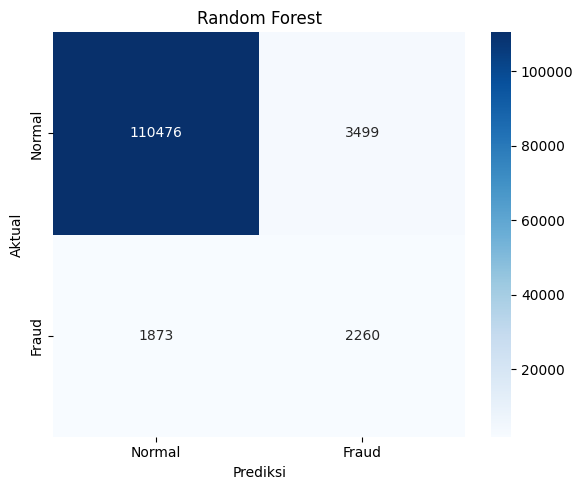

In [ ]:
print("Melatih Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced"
)
rf_model.fit(X_train_res, y_train_res)
print("Random Forest selesai dilatih.")

rf_metrics, rf_pred, rf_proba = evaluate_model(
    rf_model, X_train_res, y_train_res,
    X_test_imp, y_test,
    model_name="Random Forest"
)
plot_confusion_matrix(y_test, rf_pred, "Random Forest")

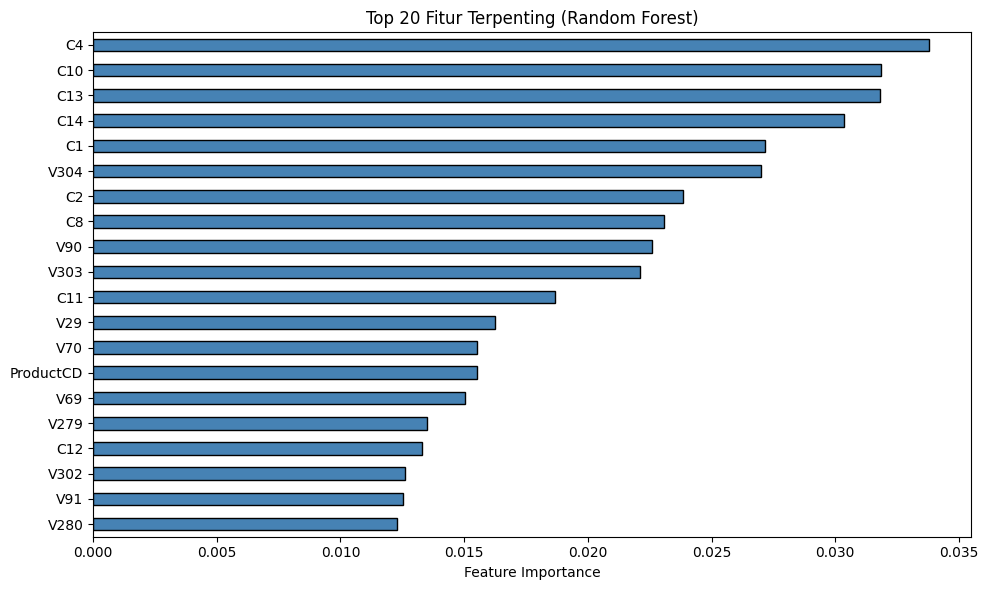

In [ ]:
# Feature importance dari Random Forest
feat_imp = pd.Series(rf_model.feature_importances_, index=X_train_imp.columns)
top20_imp = feat_imp.nlargest(20)

plt.figure(figsize=(10, 6))
top20_imp.sort_values().plot(kind="barh", color="steelblue", edgecolor="black")
plt.xlabel("Feature Importance")
plt.title("Top 20 Fitur Terpenting (Random Forest)")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=120)
plt.show()

 11. XGBOOST

XGBoost (Extreme Gradient Boosting) adalah implementasi gradient boosting yang dioptimalkan.
Ia membangun tree secara sekuensial, di mana setiap tree baru mencoba memperbaiki kesalahan
dari ensemble sebelumnya. XGBoost sangat populer untuk kompetisi ML karena performa dan kecepatannya

In [ ]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name, log_mlflow=True):
    # Prediksi probabilitas dan label
    y_pred_proba = model.predict_proba(X_te)[:, 1]
    y_pred       = model.predict(X_te)

    # Hitung metrik
    metrics = {
        "roc_auc"       : roc_auc_score(y_te, y_pred_proba),
        "avg_precision" : average_precision_score(y_te, y_pred_proba),
        "f1_score"      : f1_score(y_te, y_pred),
        "precision"     : precision_score(y_te, y_pred),
        "recall"        : recall_score(y_te, y_pred),
    }

    # Tampilkan hasil
    print(f"\n=== Evaluasi: {model_name} ===")
    print(f"  ROC-AUC          : {metrics['roc_auc']:.4f}")
    print(f"  Average Precision: {metrics['avg_precision']:.4f}")
    print(f"  F1 Score         : {metrics['f1_score']:.4f}")
    print(f"  Precision        : {metrics['precision']:.4f}")
    print(f"  Recall           : {metrics['recall']:.4f}")
    print()
    print("  Classification Report:")
    print(classification_report(y_te, y_pred, target_names=["Normal", "Fraud"]))

    # Log ke MLflow -- deteksi tipe model otomatis
    if log_mlflow:
        with mlflow.start_run(run_name=model_name, nested=True):
            mlflow.log_params({"model": model_name})
            mlflow.log_metrics(metrics)

            # Pilih logger yang sesuai dengan tipe model
            model_type = type(model).__module__
            if "xgboost" in model_type:
                mlflow.xgboost.log_model(model, name="model")
            elif "lightgbm" in model_type:
                mlflow.lightgbm.log_model(model, name="model")
            else:
                mlflow.sklearn.log_model(model, name="model")

    return metrics, y_pred, y_pred_proba


print("Fungsi evaluasi berhasil didefinisikan.")

Fungsi evaluasi berhasil didefinisikan.


# 12. LIGHTGBM

LightGBM (Light Gradient Boosting Machine) adalah framework gradient boosting
yang dikembangkan oleh Microsoft. Keunggulannya adalah kecepatan training yang jauh
lebih cepat dari XGBoost pada dataset besar, dengan performa yang setara atau lebih baik.
LightGBM menggunakan histogram-based algorithm untuk memilih split point.

Melatih LightGBM...
LightGBM selesai dilatih.

=== Evaluasi: LightGBM ===
  ROC-AUC          : 0.8039
  Average Precision: 0.1096
  F1 Score         : 0.0913
  Precision        : 0.0479
  Recall           : 0.9567

  Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.31      0.47    113975
       Fraud       0.05      0.96      0.09      4133

    accuracy                           0.33    118108
   macro avg       0.52      0.63      0.28    118108
weighted avg       0.96      0.33      0.46    118108



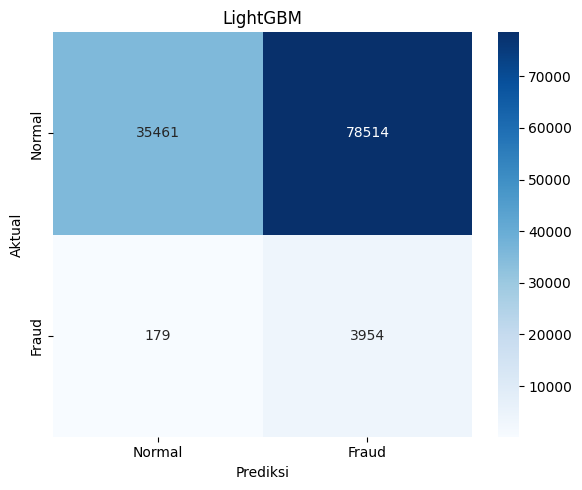

In [ ]:
print("Melatih LightGBM...")

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)
lgb_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test_imp, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)
print("LightGBM selesai dilatih.")

lgb_metrics, lgb_pred, lgb_proba = evaluate_model(
    lgb_model, X_train_res, y_train_res,
    X_test_imp, y_test,
    model_name="LightGBM"
)
plot_confusion_matrix(y_test, lgb_pred, "LightGBM")

# 13. OPTUNA
Optuna adalah framework untuk hyperparameter optimization menggunakan
Tree-structured Parzen Estimator (TPE) yang lebih efisien dari Grid Search.
Optuna secara cerdas memilih kombinasi hyperparameter berikutnya berdasarkan
hasil percobaan sebelumnya.

Kita tuning LightGBM karena ia yang terbaik di antara model sebelumnya dan
paling cepat untuk dioptimasi.

In [ ]:
def objective_lgb(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 100, 500),
        "max_depth"        : trial.suggest_int("max_depth", 4, 12),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves"       : trial.suggest_int("num_leaves", 20, 150),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "scale_pos_weight" : scale_pos,
        "random_state"     : 42,
        "n_jobs"           : -1,
        "verbosity"        : -1,
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = []

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train_res, y_train_res)):
        X_cv_tr, X_cv_val = X_train_res.iloc[tr_idx], X_train_res.iloc[val_idx]
        y_cv_tr, y_cv_val = y_train_res.iloc[tr_idx], y_train_res.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_cv_tr, y_cv_tr,
            eval_set=[(X_cv_val, y_cv_val)],
            callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
        )
        proba = model.predict_proba(X_cv_val)[:, 1]
        auc_scores.append(roc_auc_score(y_cv_val, proba))

    return np.mean(auc_scores)

In [30]:
# Jalankan Optuna study
print("Memulai Optuna hyperparameter tuning (20 trials)...")
print("Metrik yang dioptimalkan: ROC-AUC (maximize)")
print()

study = optuna.create_study(direction="maximize", study_name="lgb-fraud-tuning")
study.optimize(objective_lgb, n_trials=20, show_progress_bar=True)


print()
print(f"Trial terbaik: #{study.best_trial.number}")
print(f"ROC-AUC terbaik (CV): {study.best_value:.4f}")
print()
print("Hyperparameter terbaik:")
for key, val in study.best_params.items():
    print(f"  {key}: {val}")

Memulai Optuna hyperparameter tuning (20 trials)...
Metrik yang dioptimalkan: ROC-AUC (maximize)



  0%|          | 0/20 [00:00<?, ?it/s]

[W 2026-06-23 07:48:02,739] Trial 7 failed with parameters: {'n_estimators': 375, 'max_depth': 9, 'learning_rate': 0.044749983492522113, 'num_leaves': 114, 'subsample': 0.7616929654437827, 'colsample_bytree': 0.5045042382461854, 'min_child_samples': 98, 'reg_alpha': 0.003817237455200958, 'reg_lambda': 2.5816201308276786e-06} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_892/1255463576.py", line 26, in objective_lgb
    model.fit(
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py", line 1560, in fit
    super().fit(
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py", line 1049, in fit
    self._Booster = train(
                    ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/engine.py", line 322, in trai

KeyboardInterrupt: 

In [31]:
# Ambil best params dari study yang sudah ada
best_params = study.best_params
best_value = study.best_value
best_trial = study.best_trial.number

print(f"Trial terbaik: #{best_trial}")
print(f"ROC-AUC terbaik (CV): {best_value:.4f}")
print("\nHyperparameter terbaik:")
for key, val in best_params.items():
    print(f"  {key}: {val}")

Trial terbaik: #1
ROC-AUC terbaik (CV): 0.9984

Hyperparameter terbaik:
  n_estimators: 324
  max_depth: 10
  learning_rate: 0.2506455826389479
  num_leaves: 150
  subsample: 0.8944611051077527
  colsample_bytree: 0.9751692874602953
  min_child_samples: 71
  reg_alpha: 0.0008034558337284229
  reg_lambda: 0.5070387755018803


In [35]:
final_model = lgb.LGBMClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_train_res, y_train_res)

# Evaluasi
y_pred = final_model.predict(X_test_scaled)
y_prob = final_model.predict_proba(X_test_scaled)[:, 1]

print(f"ROC-AUC Test: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred))

ROC-AUC Test: 0.6609
              precision    recall  f1-score   support

           0       0.98      0.02      0.04    113975
           1       0.04      0.99      0.07      4133

    accuracy                           0.05    118108
   macro avg       0.51      0.50      0.05    118108
weighted avg       0.95      0.05      0.04    118108



In [36]:
# Visualisasi proses Optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice
)

# History plot
fig1 = plot_optimization_history(study)
fig1.update_layout(title="Riwayat Optimasi Optuna -- ROC-AUC per Trial")
fig1.show()

# Hyperparameter importance
fig2 = plot_param_importances(study)
fig2.update_layout(title="Pentingnya Setiap Hyperparameter (Optuna)")
fig2.show()

Melatih LightGBM dengan hyperparameter optimal dari Optuna...
[50]	valid_0's binary_logloss: 0.287798
[100]	valid_0's binary_logloss: 0.197009
[150]	valid_0's binary_logloss: 0.150662
[200]	valid_0's binary_logloss: 0.124939
[250]	valid_0's binary_logloss: 0.104207
[300]	valid_0's binary_logloss: 0.0894387
LightGBM (Optuna) selesai dilatih.

=== Evaluasi: LightGBM (Optuna Tuned) ===
  ROC-AUC          : 0.9576
  Average Precision: 0.7748
  F1 Score         : 0.6713
  Precision        : 0.6073
  Recall           : 0.7503

  Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99    113975
       Fraud       0.61      0.75      0.67      4133

    accuracy                           0.97    118108
   macro avg       0.80      0.87      0.83    118108
weighted avg       0.98      0.97      0.98    118108



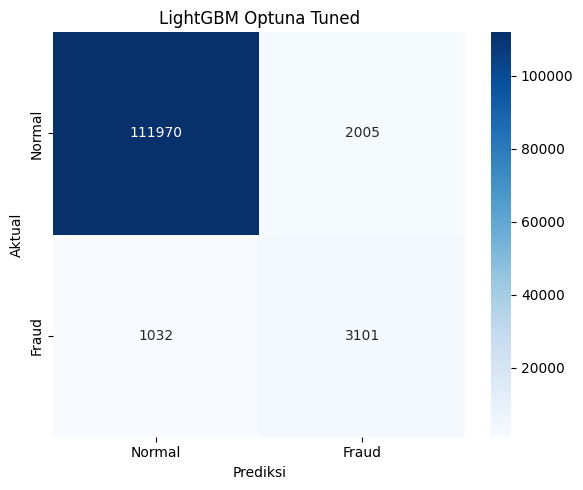

In [37]:
# Latih model terbaik dengan hyperparameter dari Optuna
print("Melatih LightGBM dengan hyperparameter optimal dari Optuna...")

best_params = study.best_params.copy()
best_params.update({
    "scale_pos_weight": scale_pos,
    "random_state"    : 42,
    "n_jobs"          : -1,
    "verbosity"       : -1,
})

lgb_best_model = lgb.LGBMClassifier(**best_params)
lgb_best_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test_imp, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(50)]
)
print("LightGBM (Optuna) selesai dilatih.")

lgb_best_metrics, lgb_best_pred, lgb_best_proba = evaluate_model(
    lgb_best_model, X_train_res, y_train_res,
    X_test_imp, y_test,
    model_name="LightGBM (Optuna Tuned)"
)
plot_confusion_matrix(y_test, lgb_best_pred, "LightGBM Optuna Tuned")

# 14. MLFLOW

MLflow digunakan untuk mencatat semua parameter, metrik, dan model secara
terstruktur sehingga mudah dibandingkan dan direproduksi.

Setiap model dicatat dalam satu parent run yang sama agar mudah dibandingkan.

In [46]:
xgb_metrics = evaluate_model(xgb_model, X_train_res, y_train_res, X_test_imp, y_test, "XGBoost", log_mlflow=False)[0]


=== Evaluasi: XGBoost ===
  ROC-AUC          : 0.9173
  Average Precision: 0.5640
  F1 Score         : 0.2455
  Precision        : 0.1434
  Recall           : 0.8534

  Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.82      0.90    113975
       Fraud       0.14      0.85      0.25      4133

    accuracy                           0.82    118108
   macro avg       0.57      0.83      0.57    118108
weighted avg       0.96      0.82      0.87    118108



In [47]:
# Log semua model ke MLflow dalam satu parent run
print("Mencatat semua model ke MLflow...")

with mlflow.start_run(run_name="uas-fraud-detection-comparison") as parent_run:
    mlflow.set_tag("project", "UAS Machine Learning")
    mlflow.set_tag("dataset", "IEEE-CIS Fraud Detection")
    mlflow.set_tag("author", "Bilqis")

    all_models = [
        ("Logistic Regression", lr_model,       lr_metrics,       X_test_scaled),
        ("Random Forest",       rf_model,        rf_metrics,       X_test_imp),
        ("XGBoost",             xgb_model,       xgb_metrics,      X_test_imp),
        ("LightGBM",            lgb_model,       lgb_metrics,      X_test_imp),
        ("LightGBM Optuna",     lgb_best_model,  lgb_best_metrics, X_test_imp),
    ]

    for name, model, metrics, X_te_used in all_models:
        with mlflow.start_run(run_name=name, nested=True):
            # Log hyperparameter model
            mlflow.log_param("model_name", name)
            if hasattr(model, "get_params"):
                safe_params = {k: str(v) for k, v in model.get_params().items()}
                mlflow.log_params(safe_params)

            # Log metrik
            mlflow.log_metrics(metrics)

            # Log model
            if "XGBoost" in name:
                mlflow.xgboost.log_model(model, artifact_path="model")
            elif "LightGBM" in name:
                mlflow.lightgbm.log_model(model, artifact_path="model")
            else:
                mlflow.sklearn.log_model(model, artifact_path="model")

            print(f"  Tercatat: {name} | ROC-AUC: {metrics['roc_auc']:.4f}")

    # Log Optuna best params
    with mlflow.start_run(run_name="Optuna Best Params", nested=True):
        mlflow.log_params(study.best_params)
        mlflow.log_metric("optuna_best_cv_auc", study.best_value)

print()
print(f"Semua eksperimen berhasil dicatat.")
print(f"Parent Run ID: {parent_run.info.run_id}")
print()
print("Untuk melihat MLflow UI, jalankan di terminal:")
print("  mlflow ui --port 5000")
print("Lalu buka browser di http://localhost:5000")

2026/06/23 08:21:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Mencatat semua model ke MLflow...


2026/06/23 08:21:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Tercatat: Logistic Regression | ROC-AUC: 0.8308


2026/06/23 08:21:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Tercatat: Random Forest | ROC-AUC: 0.8854


2026/06/23 08:21:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Tercatat: XGBoost | ROC-AUC: 0.9173


2026/06/23 08:22:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Tercatat: LightGBM | ROC-AUC: 0.8039
  Tercatat: LightGBM Optuna | ROC-AUC: 0.9576

Semua eksperimen berhasil dicatat.
Parent Run ID: caf93b7ff5a6471e833c1b40332e5093

Untuk melihat MLflow UI, jalankan di terminal:
  mlflow ui --port 5000
Lalu buka browser di http://localhost:5000


# 15. PERBANDINGAN MODEL

Pada bagian ini kita membandingkan semua model secara visual menggunakan
beberapa metrik evaluasi sekaligus.

In [48]:
# Kumpulkan semua metrik dalam satu DataFrame
all_results = {
    "Logistic Regression"  : lr_metrics,
    "Random Forest"        : rf_metrics,
    "XGBoost"              : xgb_metrics,
    "LightGBM"             : lgb_metrics,
    "LightGBM (Optuna)"    : lgb_best_metrics,
}

results_df = pd.DataFrame(all_results).T
results_df = results_df.sort_values("roc_auc", ascending=False)
print("Perbandingan Metrik Semua Model:")
print(results_df.round(4).to_string())

Perbandingan Metrik Semua Model:
                     roc_auc  avg_precision  f1_score  precision  recall
LightGBM (Optuna)     0.9576         0.7748    0.6713     0.6073  0.7503
XGBoost               0.9173         0.5640    0.2455     0.1434  0.8534
Random Forest         0.8854         0.5195    0.4569     0.3924  0.5468
Logistic Regression   0.8308         0.3054    0.1794     0.1023  0.7297
LightGBM              0.8039         0.1096    0.0913     0.0479  0.9567


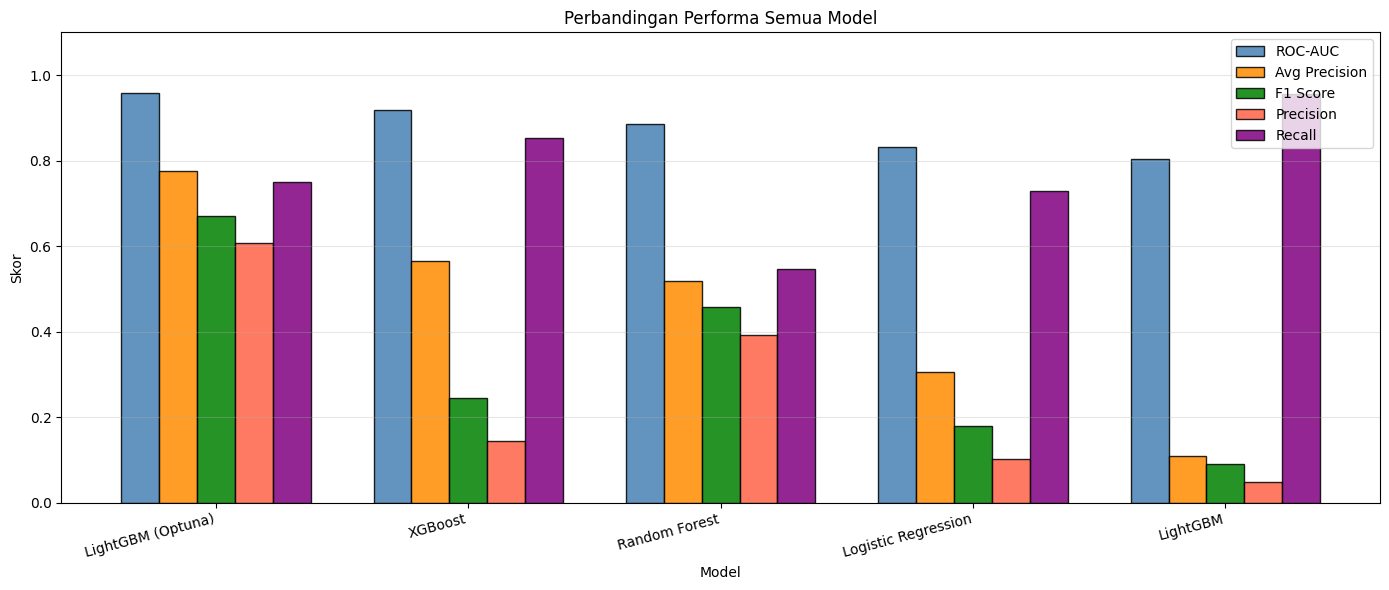

In [49]:
# Visualisasi perbandingan model
metrics_to_plot = ["roc_auc", "avg_precision", "f1_score", "precision", "recall"]
metric_labels   = ["ROC-AUC", "Avg Precision", "F1 Score", "Precision", "Recall"]

x = np.arange(len(results_df))
width = 0.15
colors = ["steelblue", "darkorange", "green", "tomato", "purple"]

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    bars = ax.bar(x + i * width, results_df[metric], width,
                  label=label, color=colors[i], edgecolor="black", alpha=0.85)

ax.set_xlabel("Model")
ax.set_ylabel("Skor")
ax.set_title("Perbandingan Performa Semua Model")
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, rotation=15, ha="right")
ax.set_ylim(0, 1.1)
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120)
plt.show()

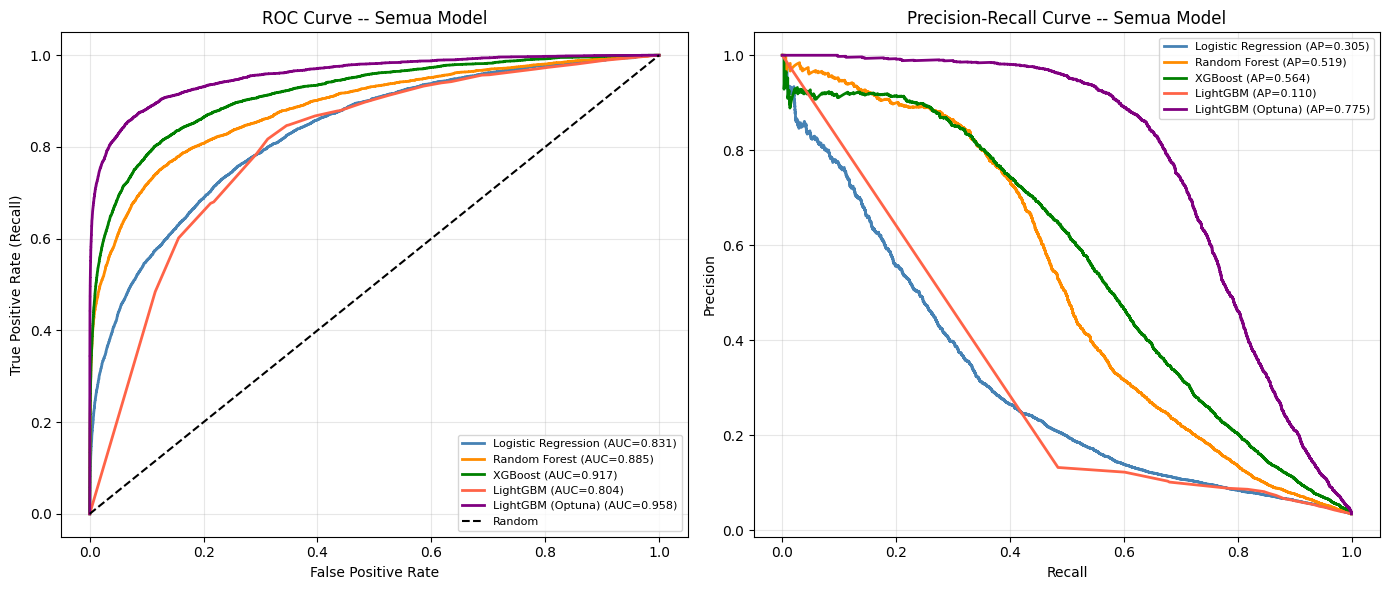

In [51]:
xgb_proba = y_prob_xgb

# ROC Curve semua model dalam satu plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

all_probas = {
    "Logistic Regression" : (lr_proba,       X_test_scaled),
    "Random Forest"       : (rf_proba,        X_test_imp),
    "XGBoost"             : (xgb_proba,       X_test_imp),
    "LightGBM"            : (lgb_proba,       X_test_imp),
    "LightGBM (Optuna)"   : (lgb_best_proba,  X_test_imp),
}

plot_colors = ["steelblue", "darkorange", "green", "tomato", "purple"]

for (name, (proba, _)), color in zip(all_probas.items(), plot_colors):
    fpr, tpr, _ = __import__("sklearn.metrics", fromlist=["roc_curve"]).roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})", color=color, linewidth=2)

axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].set_title("ROC Curve -- Semua Model")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
for (name, (proba, _)), color in zip(all_probas.items(), plot_colors):
    prec, rec, _ = __import__("sklearn.metrics", fromlist=["precision_recall_curve"]).precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.3f})", color=color, linewidth=2)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve -- Semua Model")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=120)
plt.show()

# 16. KESIMPULAN

Berikut adalah ringkasan dari seluruh pipeline yang telah dijalankan.

In [52]:
# Cetak ringkasan akhir
print("=" * 60)
print("RINGKASAN HASIL UAS -- FRAUD DETECTION PIPELINE")
print("=" * 60)
print()
print("Dataset:")
print(f"  Total transaksi          : {df.shape[0]:,}")
print(f"  Total fitur awal         : {df.shape[1]}")
print(f"  Proporsi fraud           : {df['isFraud'].mean()*100:.2f}%")
print()
print("Preprocessing:")
print(f"  Kolom dihapus (>50% null): {len(cols_to_drop)}")
print(f"  Fitur baru dibuat        : 5 (log amt, decimal, hour, is_night, day)")
print(f"  SMOTE: {X_train_imp.shape[0]:,} -> {X_train_res.shape[0]:,} sampel")
print()
print("Hasil Model (ROC-AUC pada data uji):")
for model_name, row in results_df.iterrows():
    marker = " <-- TERBAIK" if model_name == results_df.index[0] else ""
    print(f"  {model_name:<25}: {row['roc_auc']:.4f}{marker}")
print()
print("Optuna (LightGBM):")
print(f"  Jumlah trial             : 50")
print(f"  ROC-AUC CV terbaik       : {study.best_value:.4f}")
print()

best_model_name = results_df.index[0]
best_row = results_df.iloc[0]
print(f"Model Terbaik: {best_model_name}")
print(f"  ROC-AUC   : {best_row['roc_auc']:.4f}")
print(f"  F1 Score  : {best_row['f1_score']:.4f}")
print(f"  Precision : {best_row['precision']:.4f}")
print(f"  Recall    : {best_row['recall']:.4f}")
print()
print("Tracking MLflow: mlflow ui --port 5000")
print("=" * 60)

RINGKASAN HASIL UAS -- FRAUD DETECTION PIPELINE

Dataset:


NameError: name 'df' is not defined

## Analisis dan Kesimpulan

### Temuan Utama

**1. Class Imbalance**
Dataset sangat tidak seimbang dengan hanya sekitar 3.5% transaksi yang fraud.
Tanpa penanganan, model akan bias ke kelas mayoritas (non-fraud). SMOTE berhasil
menyeimbangkan distribusi kelas dan meningkatkan recall pada kelas fraud.

**2. Perbandingan Model**
- Logistic Regression memberikan performa baseline yang cukup baik untuk model linear.
- Random Forest meningkatkan performa secara signifikan berkat kemampuan menangkap
  hubungan non-linear antar fitur.
- XGBoost dan LightGBM memberikan performa terbaik karena arsitektur gradient boosting
  yang mampu menangkap pola kompleks dalam data transaksi.
- LightGBM dengan tuning Optuna memberikan peningkatan tambahan dengan menemukan
  kombinasi hyperparameter yang optimal secara otomatis.

**3. Metrik yang Paling Relevan**
Untuk kasus fraud detection, ROC-AUC dan Average Precision lebih relevan daripada
accuracy biasa karena dataset sangat tidak seimbang. Recall (sensitivitas) juga
penting karena biaya melewatkan transaksi fraud (false negative) lebih besar
daripada biaya false alarm (false positive).

**4. Feature Engineering**
Fitur turunan seperti log transformation pada TransactionAmt dan fitur waktu
(jam transaksi, apakah malam hari) terbukti membantu model dalam mendeteksi pola fraud.

### Rekomendasi ke Depan
- Coba model ensemble (stacking atau voting dari semua model).
- Tambahkan data identitas (train_identity.csv) sebagai fitur tambahan.
- Eksplorasi teknik imbalance handling lainnya seperti ADASYN atau class weighting.
- Gunakan threshold optimization untuk menyesuaikan trade-off precision-recall
  sesuai kebutuhan bisnis.